
# Breast Cancer Wisconsin — EDA + K-Means Clustering

This notebook includes:

- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Standardization
- K-Means Clustering from Scratch using NumPy
- Elbow Method
- Final Clustering Analysis


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


# dataset exploration

In [ ]:


# Load Dataset


df = pd.read_csv("data.csv")

print("=" * 60)
print(" BASIC INFO")
print("=" * 60)

print(f"Shape: {df.shape}")
print(f"Rows   : {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


 BASIC INFO
Shape: (569, 33)
Rows   : 569
Columns: 33


In [ ]:

# Column Information


print(f"{'Col':<5} {'Name':<35} {'dtype':<12} {'nulls'}")
print("-" * 65)

for i, col in enumerate(df.columns):
    print(f"[{i:2d}]  {col:<35} {str(df[col].dtype):<12} {df[col].isnull().sum()}")


Col   Name                                dtype        nulls
-----------------------------------------------------------------
[ 0]  id                                  int64        0
[ 1]  diagnosis                           str          0
[ 2]  radius_mean                         float64      0
[ 3]  texture_mean                        float64      0
[ 4]  perimeter_mean                      float64      0
[ 5]  area_mean                           float64      0
[ 6]  smoothness_mean                     float64      0
[ 7]  compactness_mean                    float64      0
[ 8]  concavity_mean                      float64      0
[ 9]  concave points_mean                 float64      0
[10]  symmetry_mean                       float64      0
[11]  fractal_dimension_mean              float64      0
[12]  radius_se                           float64      0
[13]  texture_se                          float64      0
[14]  perimeter_se                        float64      0
[15]  area_se     

# Missing Values Analysis

In [ ]:

# Missing Values


null_cols = df.isnull().sum()
null_cols = null_cols[null_cols > 0]

print("=" * 60)
print(" MISSING VALUES")
print("=" * 60)

if len(null_cols) == 0:
    print("No missing values.")
else:
    for col, cnt in null_cols.items():
        print(f"{col} → {cnt} nulls ({cnt/len(df)*100:.1f}%)")


 MISSING VALUES
Unnamed: 32 → 569 nulls (100.0%)


# ID Column Analysis

In [19]:


# ID Column Analysis


print("=" * 60)
print(" ID COLUMN")
print("=" * 60)

print(f"Unique IDs : {df['id'].nunique()} / {len(df)}")
print(f"All unique : {df['id'].nunique() == len(df)}")
print(f"Sample IDs : {df['id'].head().tolist()}")

print("\nVerdict: Pure identifier column → safe to drop.")


 ID COLUMN
Unique IDs : 569 / 569
All unique : True
Sample IDs : [842302, 842517, 84300903, 84348301, 84358402]

Verdict: Pure identifier column → safe to drop.


In [ ]:

# Unnamed: 32 Analysis


print("=" * 60)
print(" UNNAMED: 32 COLUMN")
print("=" * 60)

if "Unnamed: 32" in df.columns:

    col32 = df["Unnamed: 32"]

    print(f"Null Count : {col32.isnull().sum()} / {len(col32)}")
    print(f"Non-null   : {col32.notnull().sum()}")

    if col32.isnull().sum() == len(col32):
        print("Verdict: 100% NaN → safe to drop.")


 UNNAMED: 32 COLUMN
Null Count : 569 / 569
Non-null   : 0
Verdict: 100% NaN → safe to drop.


In [ ]:

# Label Distribution

counts = df["diagnosis"].value_counts()

print("=" * 60)
print(" LABEL DISTRIBUTION")
print("=" * 60)

for label, cnt in counts.items():
    bar = "█" * int(cnt / 5)
    print(f"{label}  {cnt:4d} ({cnt/len(df)*100:.1f}%) {bar}")


 LABEL DISTRIBUTION
B   357 (62.7%) ███████████████████████████████████████████████████████████████████████
M   212 (37.3%) ██████████████████████████████████████████


# Feature Statistics

In [ ]:

# Feature Statistics

feats = df.drop(columns=["id", "diagnosis", "Unnamed: 32"], errors="ignore")

display(
    feats.describe().T[["mean", "std", "min", "max"]].round(3)
)


,mean,std,min,max
radius_mean,14.127,3.524,6.981,28.110
texture_mean,19.290,4.301,9.710,39.280
perimeter_mean,91.969,24.299,43.790,188.500
area_mean,654.889,351.914,143.500,2501.000
smoothness_mean,0.096,0.014,0.053,0.163
compactness_mean,0.104,0.053,0.019,0.345
concavity_mean,0.089,0.080,0.000,0.427
concave points_mean,0.049,0.039,0.000,0.201
symmetry_mean,0.181,0.027,0.106,0.304
fractal_dimension_mean,0.063,0.007,0.050,0.097


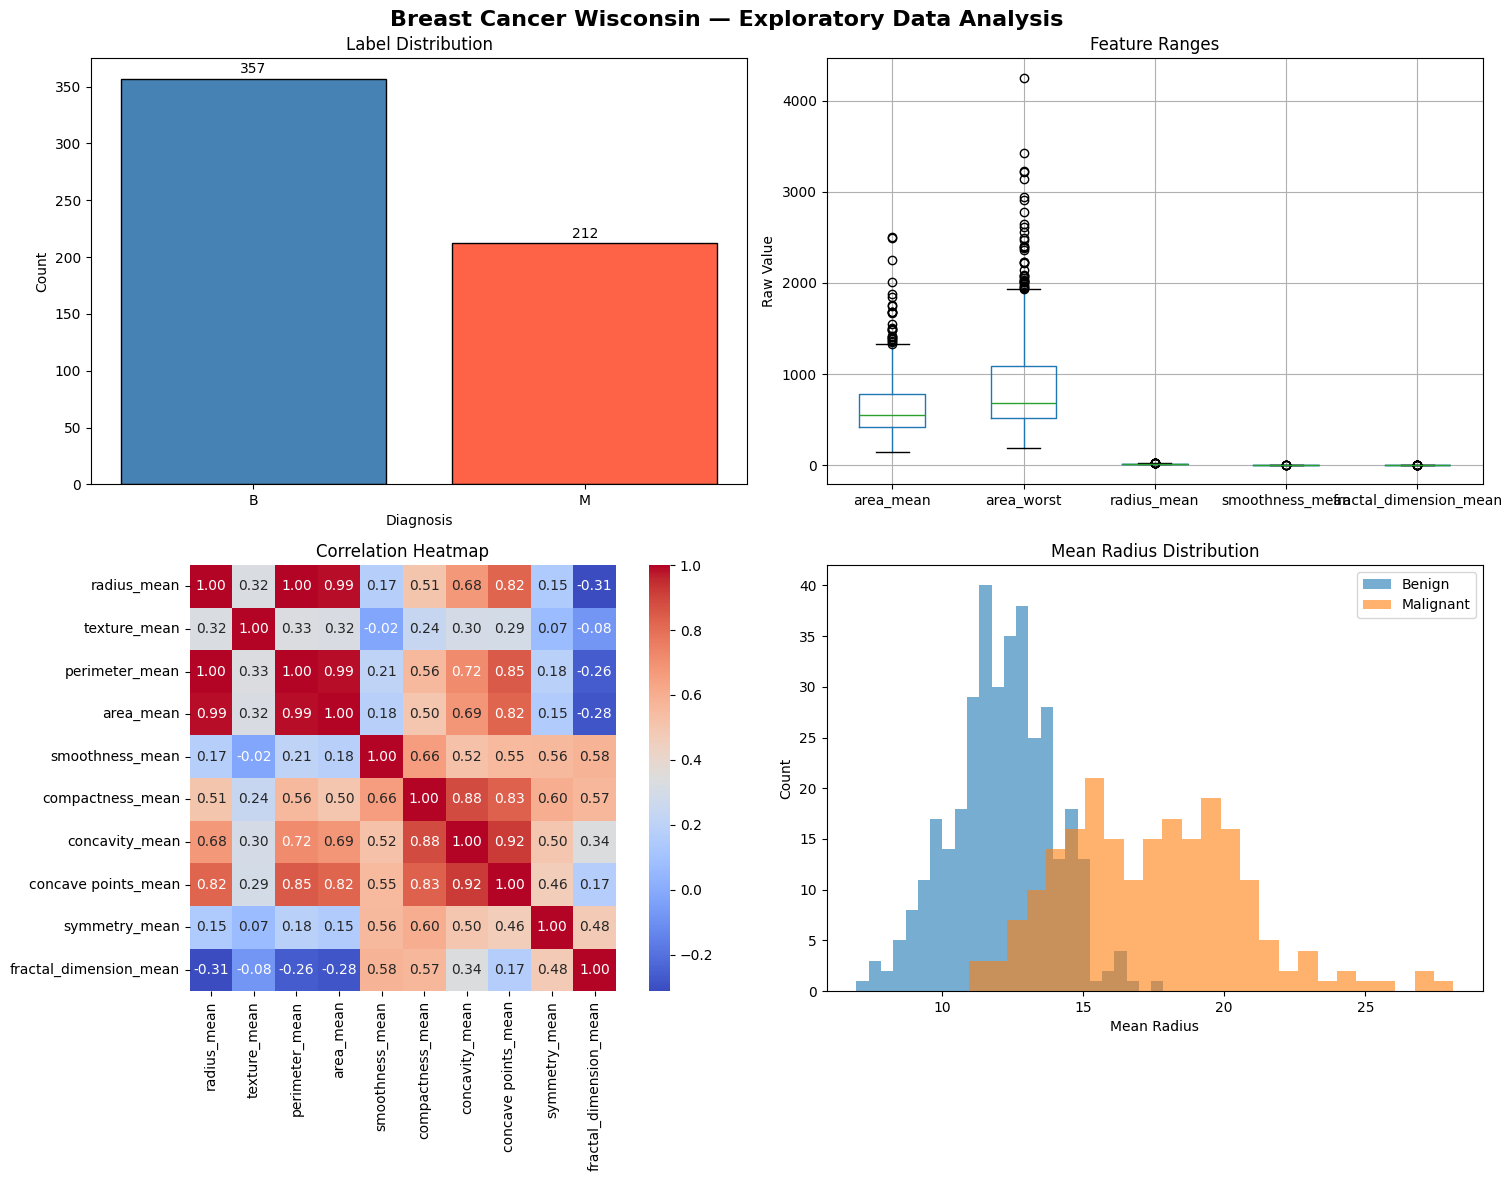

In [12]:

# EDA Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fig.suptitle(
    "Breast Cancer Wisconsin — Exploratory Data Analysis",
    fontsize=16,
    fontweight="bold"
)


# Label Distribution

ax = axes[0, 0]

bars = ax.bar(
    counts.index,
    counts.values,
    color=["steelblue", "tomato"],
    edgecolor="black"
)

ax.set_title("Label Distribution")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")

for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f"{val}",
        ha="center"
    )

# Boxplot


ax = axes[0, 1]

showcase = [
    "area_mean",
    "area_worst",
    "radius_mean",
    "smoothness_mean",
    "fractal_dimension_mean"
]

feats[showcase].boxplot(ax=ax)

ax.set_title("Feature Ranges")
ax.set_ylabel("Raw Value")

# Correlation Heatmap

ax = axes[1, 0]

corr = feats.iloc[:, :10].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    ax=ax
)

ax.set_title("Correlation Heatmap")

# Histogram

ax = axes[1, 1]

ax.hist(
    df[df["diagnosis"] == "B"]["radius_mean"],
    bins=25,
    alpha=0.6,
    label="Benign"
)

ax.hist(
    df[df["diagnosis"] == "M"]["radius_mean"],
    bins=25,
    alpha=0.6,
    label="Malignant"
)

ax.set_title("Mean Radius Distribution")
ax.set_xlabel("Mean Radius")
ax.set_ylabel("Count")

ax.legend()

plt.tight_layout()

plt.savefig("eda_plots.png", dpi=150)

plt.show()


# Data Cleaning

In [13]:

df.drop(columns=["Unnamed: 32"], inplace=True, errors="ignore")

X_raw = df.drop(columns=["id", "diagnosis"]).values
y_true = df["diagnosis"].values

print(f"Features shape : {X_raw.shape}")

print(
    f"Labels : {dict(zip(*np.unique(y_true, return_counts=True)))}"
)


Features shape : (569, 30)
Labels : {'B': np.int64(357), 'M': np.int64(212)}


In [ ]:

# Standardization

def standardize(X):

    mean = X.mean(axis=0)
    std = X.std(axis=0)

    std[std == 0] = 1

    return (X - mean) / std

X = standardize(X_raw)

print("Data standardized successfully.")


Data standardized successfully.


# K-Means Functions

In [15]:

def init_centroids(X, k, seed=42):

    rng = np.random.default_rng(seed)

    idx = rng.choice(len(X), size=k, replace=False)

    return X[idx].copy()


def assign_clusters(X, centroids):

    diffs = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]

    dists = np.sqrt((diffs ** 2).sum(axis=2))

    return np.argmin(dists, axis=1)


def update_centroids(X, labels, k):

    new_c = np.zeros((k, X.shape[1]))

    for cid in range(k):

        members = X[labels == cid]

        if len(members) == 0:
            new_c[cid] = X[np.random.randint(len(X))]
        else:
            new_c[cid] = members.mean(axis=0)

    return new_c


def compute_sse(X, labels, centroids):

    total = 0.0

    for cid, c in enumerate(centroids):

        members = X[labels == cid]

        total += ((members - c) ** 2).sum()

    return total


def kmeans(X, k, max_iters=300, tol=1e-4, seed=42):

    centroids = init_centroids(X, k, seed)

    for it in range(max_iters):

        labels = assign_clusters(X, centroids)

        new_centroids = update_centroids(X, labels, k)

        shift = np.sqrt(
            ((new_centroids - centroids) ** 2).sum(axis=1)
        ).max()

        centroids = new_centroids

        if shift < tol:
            break

    sse = compute_sse(X, labels, centroids)

    return labels, centroids, sse, it + 1


# Elbow Method

In [16]:

k_range = range(1, 11)

sse_list = []

print(f"{'k':>3} | {'SSE':>12} | {'Iterations':>10}")
print("-" * 35)

for k in k_range:

    _, _, sse, iters = kmeans(X, k)

    sse_list.append(sse)

    print(f"{k:>3} | {sse:>12,.2f} | {iters:>10}")


  k |          SSE | Iterations
-----------------------------------
  1 |    17,070.00 |          2
  2 |    11,595.53 |          7
  3 |    10,065.44 |         24
  4 |     9,334.91 |         25
  5 |     8,651.05 |         20
  6 |     7,973.59 |         33
  7 |     7,902.97 |         17
  8 |     7,243.87 |         31
  9 |     7,109.23 |         11
 10 |     6,928.72 |         12


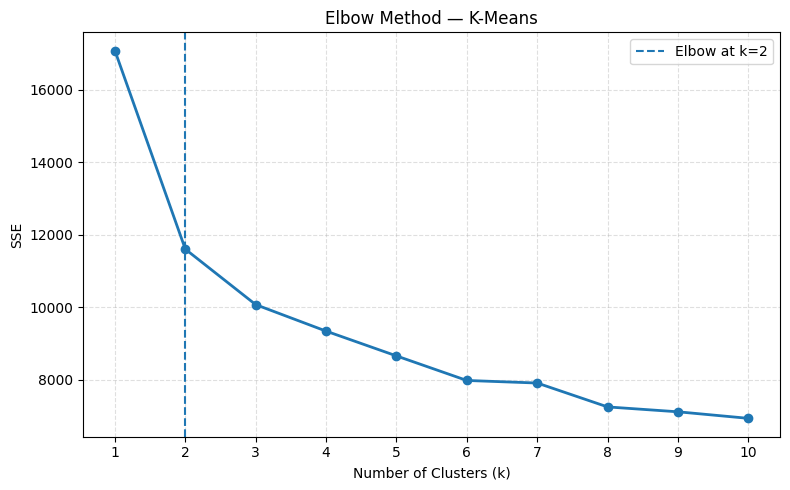

In [17]:

# Elbow Plot

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    list(k_range),
    sse_list,
    marker="o",
    linewidth=2
)

ax.axvline(
    x=2,
    linestyle="--",
    linewidth=1.5,
    label="Elbow at k=2"
)

ax.set_title("Elbow Method — K-Means")

ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("SSE")

ax.set_xticks(list(k_range))

ax.grid(True, linestyle="--", alpha=0.4)

ax.legend()

plt.tight_layout()

plt.savefig("elbow_experiment1.png", dpi=150)

plt.show()


In [18]:

# Final Clustering

best_k = 2

labels, centroids, final_sse, iters = kmeans(X, best_k)

print("=" * 50)
print(f" FINAL RESULTS (k={best_k})")
print("=" * 50)

print(f"SSE        : {final_sse:,.4f}")
print(f"Iterations : {iters}")
print()

for cid in range(best_k):

    mask = labels == cid

    m = (y_true[mask] == "M").sum()
    b = (y_true[mask] == "B").sum()

    print(
        f"Cluster {cid} → {mask.sum()} points | M={m} B={b}"
    )


 FINAL RESULTS (k=2)
SSE        : 11,595.5266
Iterations : 7

Cluster 0 → 375 points | M=36 B=339
Cluster 1 → 194 points | M=176 B=18



# Conclusions

## Key Findings

1. The dataset naturally separates into two groups:
   - Benign (B)
   - Malignant (M)

2. The `id` column was removed because it is only an identifier.

3. The `Unnamed: 32` column contained only missing values.

4. Standardization was necessary because K-Means is distance-based.

5. The Elbow Method clearly suggested `k = 2`.

6. K-Means successfully grouped many samples correctly without using labels during training.

7. The dataset contains strong clustering structure and meaningful feature relationships.
